In [2]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path.cwd().parent / "Data"   # notebook lives in Sprinkhaan/Notebooks

df = pd.read_csv(DATA_DIR / "patient_history.csv", dtype=str)

print(df.shape)
df.head()


(6825, 21)


,patient_id,age,sex,admission_date,discharge_date,actual_los,adm_type,primary_diagnosis_code,secondary_diagnosis_codes,bmi,...,diastolic_bp,heart_rate,temperature,admission_notes,discharge_notes,attending_physician_id,insurance_provider,room_number,bed_number,discharge_reason
0,PAT-05580,50,F,01/01/2019,2019-01-08,7,T,N18.3,N17.9; A41.51,31.0,...,74.0,65.0,37.2,Patient admitted in stable condition. Alert an...,Discharge delayed on several occasions due to ...,PHY-10,CZ,4C-06,B,Recovered
1,PAT-05526,60,F,01/01/2023,2023-01-06,5,E,G40.909,NaN,NaN,...,86.0,88.0,37.0,Patient admitted in stable condition. Alert an...,Uncomplicated admission. Responded well to tre...,PHY-14,VGZ,4C-02,B,Recovered
2,PAT-01673,85,M,01/02/2018,2018-01-22,20,P,R65.20,I21.9; I20.9; G40.909,19.7,...,102.0,129.0,37.4,Patient in no acute distress on arrival. Vital...,Complex and extended stay. Patient required pe...,PHY-16,ONVZ,4C-01,A,Recovered
3,PAT-01163,51,F,01/03/2012,2012-01-14,11,P,J18.9,E11.9,31.3,...,78.0,95.0,37.4,Admission requiring immediate stabilisation on...,Patient's recovery slower than anticipated. Fu...,PHY-21,VGZ,4C-08,A,Recovered
4,PAT-04550,69,M,01/03/2012,2012-01-09,6,P,J18.9,NaN,26.5,...,67.0,98.0,37.6,Patient in no acute distress on arrival. Vital...,Patient discharged home in good condition. All...,PHY-09,Zilveren Kruis,4C-06,A,Recovered


In [3]:
# datum notitie klopt niet, is nu aangepast in format

def parse_mixed_dates(s):
    """admission_date mixes ISO, day-first slash, and 'April 04, 2012' styles."""
    out = pd.to_datetime(s, format="%Y-%m-%d", errors="coerce")
    out = out.fillna(pd.to_datetime(s, format="%d/%m/%Y", errors="coerce"))
    out = out.fillna(pd.to_datetime(s, format="%B %d, %Y", errors="coerce"))
    return out

df["admission_date"] = parse_mixed_dates(df["admission_date"])
df["discharge_date"] = pd.to_datetime(df["discharge_date"], format="%Y-%m-%d", errors="coerce")

num_cols = ["age", "actual_los", "bmi", "systolic_bp", "diastolic_bp", "heart_rate", "temperature"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

# nothing should be left unparsed
print("unparsed admission_date:", df["admission_date"].isna().sum())
df.dtypes

print(df.shape)
df.head()


unparsed admission_date: 210
(6825, 21)


,patient_id,age,sex,admission_date,discharge_date,actual_los,adm_type,primary_diagnosis_code,secondary_diagnosis_codes,bmi,...,diastolic_bp,heart_rate,temperature,admission_notes,discharge_notes,attending_physician_id,insurance_provider,room_number,bed_number,discharge_reason
0,PAT-05580,50,F,2019-01-01,2019-01-08,7,T,N18.3,N17.9; A41.51,31.0,...,74.0,65.0,37.2,Patient admitted in stable condition. Alert an...,Discharge delayed on several occasions due to ...,PHY-10,CZ,4C-06,B,Recovered
1,PAT-05526,60,F,2023-01-01,2023-01-06,5,E,G40.909,NaN,NaN,...,86.0,88.0,37.0,Patient admitted in stable condition. Alert an...,Uncomplicated admission. Responded well to tre...,PHY-14,VGZ,4C-02,B,Recovered
2,PAT-01673,85,M,2018-02-01,2018-01-22,20,P,R65.20,I21.9; I20.9; G40.909,19.7,...,102.0,129.0,37.4,Patient in no acute distress on arrival. Vital...,Complex and extended stay. Patient required pe...,PHY-16,ONVZ,4C-01,A,Recovered
3,PAT-01163,51,F,2012-03-01,2012-01-14,11,P,J18.9,E11.9,31.3,...,78.0,95.0,37.4,Admission requiring immediate stabilisation on...,Patient's recovery slower than anticipated. Fu...,PHY-21,VGZ,4C-08,A,Recovered
4,PAT-04550,69,M,2012-03-01,2012-01-09,6,P,J18.9,NaN,26.5,...,67.0,98.0,37.6,Patient in no acute distress on arrival. Vital...,Patient discharged home in good condition. All...,PHY-09,Zilveren Kruis,4C-06,A,Recovered


In [4]:
#HEt klopt nog niet met de notitie van de data, nu correcte code
# One caveat worth being explicit about: this uses actual_los to reconstruct admission_date. Fine for cleaning, but it means admission_date is no longer independent of actual_los

from pathlib import Path
import pandas as pd

DATA_DIR = Path.cwd().parent / "Data"
df = pd.read_csv(DATA_DIR / "patient_history.csv", dtype=str)

p = lambda s, fmt: pd.to_datetime(s, format=fmt, errors="coerce")

iso   = p(df.admission_date, "%Y-%m-%d")
dayf  = p(df.admission_date, "%d/%m/%Y")
monf  = p(df.admission_date, "%m/%d/%Y")
lng   = p(df.admission_date, "%B %d, %Y")

discharge = p(df.discharge_date, "%Y-%m-%d")
los       = pd.to_numeric(df.actual_los, errors="coerce")

# Slash dates mix day-first and month-first, so resolve each row by whichever
# reading reproduces actual_los; fall back to day-first if neither does.
day_ok = (discharge - dayf).dt.days == los
mon_ok = (discharge - monf).dt.days == los

df["admission_date"] = (
    iso.fillna(monf.where(mon_ok))
       .fillna(dayf.where(day_ok))
       .fillna(dayf)
       .fillna(lng)
)
df["discharge_date"] = discharge

num_cols = ["age", "actual_los", "bmi", "systolic_bp",
            "diastolic_bp", "heart_rate", "temperature"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

computed = (df.discharge_date - df.admission_date).dt.days
print("unparsed admission_date:", df.admission_date.isna().sum())
print("LOS mismatches:", (computed != df.actual_los).sum())
print("negative LOS:", (computed < 0).sum())

print(df.shape)
df.head()


unparsed admission_date: 0
LOS mismatches: 0
negative LOS: 0
(6825, 21)


,patient_id,age,sex,admission_date,discharge_date,actual_los,adm_type,primary_diagnosis_code,secondary_diagnosis_codes,bmi,...,diastolic_bp,heart_rate,temperature,admission_notes,discharge_notes,attending_physician_id,insurance_provider,room_number,bed_number,discharge_reason
0,PAT-05580,50,F,2019-01-01,2019-01-08,7,T,N18.3,N17.9; A41.51,31.0,...,74.0,65.0,37.2,Patient admitted in stable condition. Alert an...,Discharge delayed on several occasions due to ...,PHY-10,CZ,4C-06,B,Recovered
1,PAT-05526,60,F,2023-01-01,2023-01-06,5,E,G40.909,NaN,NaN,...,86.0,88.0,37.0,Patient admitted in stable condition. Alert an...,Uncomplicated admission. Responded well to tre...,PHY-14,VGZ,4C-02,B,Recovered
2,PAT-01673,85,M,2018-01-02,2018-01-22,20,P,R65.20,I21.9; I20.9; G40.909,19.7,...,102.0,129.0,37.4,Patient in no acute distress on arrival. Vital...,Complex and extended stay. Patient required pe...,PHY-16,ONVZ,4C-01,A,Recovered
3,PAT-01163,51,F,2012-01-03,2012-01-14,11,P,J18.9,E11.9,31.3,...,78.0,95.0,37.4,Admission requiring immediate stabilisation on...,Patient's recovery slower than anticipated. Fu...,PHY-21,VGZ,4C-08,A,Recovered
4,PAT-04550,69,M,2012-01-03,2012-01-09,6,P,J18.9,NaN,26.5,...,67.0,98.0,37.6,Patient in no acute distress on arrival. Vital...,Patient discharged home in good condition. All...,PHY-09,Zilveren Kruis,4C-06,A,Recovered


In [6]:
# check actual_los op data notaties die niet veranderd zijn
# 6,549 rows (96%), discharge_date − admission_date equals actual_los exactly. Those are the rows where the admission date was pinned by the file's own formatting 
# So: solid grounds to trust actual_los as consistent with the rest of the file, no grounds yet to call it externally correct. Whether that gap matters depends on what you're doing — for modelling LOS it's usually fine, since you'd be predicting the recorded value anyway
# 

from pathlib import Path
import pandas as pd

DATA_DIR = Path.cwd().parent / "Data"
df = pd.read_csv(DATA_DIR / "patient_history.csv", dtype=str)

p = lambda s, fmt: pd.to_datetime(s, format=fmt, errors="coerce")

iso  = p(df.admission_date, "%Y-%m-%d")
dayf = p(df.admission_date, "%d/%m/%Y")
monf = p(df.admission_date, "%m/%d/%Y")
lng  = p(df.admission_date, "%B %d, %Y")

discharge = p(df.discharge_date, "%Y-%m-%d")
los       = pd.to_numeric(df.actual_los, errors="coerce")

# Slash dates mix day-first and month-first, so resolve each row by whichever
# reading reproduces actual_los; fall back to day-first if neither does.
day_ok = (discharge - dayf).dt.days == los
mon_ok = (discharge - monf).dt.days == los

df["admission_date"] = (
    iso.fillna(monf.where(mon_ok))
       .fillna(dayf.where(day_ok))
       .fillna(dayf)
       .fillna(lng)
)
df["discharge_date"] = discharge

num_cols = ["age", "actual_los", "bmi", "systolic_bp",
            "diastolic_bp", "heart_rate", "temperature"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

computed = (df.discharge_date - df.admission_date).dt.days
print("unparsed admission_date:", df.admission_date.isna().sum())
print("LOS mismatches:", (computed != df.actual_los).sum())
print("negative LOS:", (computed < 0).sum())
print(df.shape)
df.head()


unparsed admission_date: 0
LOS mismatches: 0
negative LOS: 0
(6825, 21)


,patient_id,age,sex,admission_date,discharge_date,actual_los,adm_type,primary_diagnosis_code,secondary_diagnosis_codes,bmi,...,diastolic_bp,heart_rate,temperature,admission_notes,discharge_notes,attending_physician_id,insurance_provider,room_number,bed_number,discharge_reason
0,PAT-05580,50,F,2019-01-01,2019-01-08,7,T,N18.3,N17.9; A41.51,31.0,...,74.0,65.0,37.2,Patient admitted in stable condition. Alert an...,Discharge delayed on several occasions due to ...,PHY-10,CZ,4C-06,B,Recovered
1,PAT-05526,60,F,2023-01-01,2023-01-06,5,E,G40.909,NaN,NaN,...,86.0,88.0,37.0,Patient admitted in stable condition. Alert an...,Uncomplicated admission. Responded well to tre...,PHY-14,VGZ,4C-02,B,Recovered
2,PAT-01673,85,M,2018-01-02,2018-01-22,20,P,R65.20,I21.9; I20.9; G40.909,19.7,...,102.0,129.0,37.4,Patient in no acute distress on arrival. Vital...,Complex and extended stay. Patient required pe...,PHY-16,ONVZ,4C-01,A,Recovered
3,PAT-01163,51,F,2012-01-03,2012-01-14,11,P,J18.9,E11.9,31.3,...,78.0,95.0,37.4,Admission requiring immediate stabilisation on...,Patient's recovery slower than anticipated. Fu...,PHY-21,VGZ,4C-08,A,Recovered
4,PAT-04550,69,M,2012-01-03,2012-01-09,6,P,J18.9,NaN,26.5,...,67.0,98.0,37.6,Patient in no acute distress on arrival. Vital...,Patient discharged home in good condition. All...,PHY-09,Zilveren Kruis,4C-06,A,Recovered


In [7]:
lookup = pd.read_csv(DATA_DIR / "diagnosis_lookup.csv", dtype=str)
lookup["typical_los_benchmark"] = pd.to_numeric(lookup.typical_los_benchmark)

before = len(df)
df = df.merge(
    lookup[["icd_code", "diagnosis_category", "typical_los_benchmark"]],
    left_on="primary_diagnosis_code",
    right_on="icd_code",
    how="left",
).drop(columns="icd_code")

assert len(df) == before, f"join changed row count: {before} -> {len(df)}"
assert df.diagnosis_category.notna().all(), "some codes did not match the lookup"

df["diagnosis_category"] = df.diagnosis_category.astype("category")

print(df.diagnosis_category.value_counts().to_string())
df[["patient_id", "primary_diagnosis_code", "diagnosis_category", "actual_los"]].head()


diagnosis_category
Cardiovascular      1611
Respiratory         1421
Metabolic            863
Renal                769
Gastrointestinal     743
Infectious           640
Neurological         400
Other                378


,patient_id,primary_diagnosis_code,diagnosis_category,actual_los
0,PAT-05580,N18.3,Renal,7
1,PAT-05526,G40.909,Neurological,5
2,PAT-01673,R65.20,Infectious,20
3,PAT-01163,J18.9,Respiratory,11
4,PAT-04550,J18.9,Respiratory,6


In [8]:
# Colom toegevoegd met de uitleg van de ICD code primaire diagnoses

before = len(df)
df = df.merge(
    lookup[["icd_code", "description"]].rename(columns={"description": "diagnosis_description"}),
    left_on="primary_diagnosis_code",
    right_on="icd_code",
    how="left",
).drop(columns="icd_code")

assert len(df) == before, f"join changed row count: {before} -> {len(df)}"
assert df.diagnosis_description.notna().all(), "some codes did not match the lookup"

df[["patient_id", "primary_diagnosis_code", "diagnosis_description", "diagnosis_category"]].head(10)


,patient_id,primary_diagnosis_code,diagnosis_description,diagnosis_category
0,PAT-05580,N18.3,"Chronic kidney disease, stage 3",Renal
1,PAT-05526,G40.909,"Epilepsy, unspecified, not intractable",Neurological
2,PAT-01673,R65.20,Severe sepsis without septic shock,Infectious
3,PAT-01163,J18.9,"Pneumonia, unspecified organism",Respiratory
4,PAT-04550,J18.9,"Pneumonia, unspecified organism",Respiratory
5,PAT-01408,J18.9,"Pneumonia, unspecified organism",Respiratory
6,PAT-02430,K29.70,"Gastritis, unspecified, without bleeding",Gastrointestinal
7,PAT-03674,J22,"Acute lower respiratory infection, unspecified",Respiratory
8,PAT-05949,N20.0,Calculus of kidney,Renal
9,PAT-01410,G93.40,"Encephalopathy, unspecified",Neurological


In [10]:
df.head(2)

,patient_id,age,sex,admission_date,discharge_date,actual_los,adm_type,primary_diagnosis_code,secondary_diagnosis_codes,bmi,...,admission_notes,discharge_notes,attending_physician_id,insurance_provider,room_number,bed_number,discharge_reason,diagnosis_category,typical_los_benchmark,diagnosis_description
0,PAT-05580,50,F,2019-01-01,2019-01-08,7,T,N18.3,N17.9; A41.51,31.0,...,Patient admitted in stable condition. Alert an...,Discharge delayed on several occasions due to ...,PHY-10,CZ,4C-06,B,Recovered,Renal,4.9,"Chronic kidney disease, stage 3"
1,PAT-05526,60,F,2023-01-01,2023-01-06,5,E,G40.909,NaN,NaN,...,Patient admitted in stable condition. Alert an...,Uncomplicated admission. Responded well to tre...,PHY-14,VGZ,4C-02,B,Recovered,Neurological,4.2,"Epilepsy, unspecified, not intractable"


In [11]:
sec = df.secondary_diagnosis_codes.fillna("")
df["n_secondary"] = sec.apply(
    lambda s: len([c for c in s.split(";") if c.strip()])
)

print(df.n_secondary.value_counts().sort_index().to_string())
print()
print(df.groupby("n_secondary").actual_los.agg(["count", "mean", "median"]).round(2).to_string())




n_secondary
0    2684
1    2383
2    1262
3     496

             count   mean  median
n_secondary                      
0             2684   7.55     7.0
1             2383   8.89     8.0
2             1262  10.20    10.0
3              496  12.10    12.0


In [12]:
df.head(2)

,patient_id,age,sex,admission_date,discharge_date,actual_los,adm_type,primary_diagnosis_code,secondary_diagnosis_codes,bmi,...,discharge_notes,attending_physician_id,insurance_provider,room_number,bed_number,discharge_reason,diagnosis_category,typical_los_benchmark,diagnosis_description,n_secondary
0,PAT-05580,50,F,2019-01-01,2019-01-08,7,T,N18.3,N17.9; A41.51,31.0,...,Discharge delayed on several occasions due to ...,PHY-10,CZ,4C-06,B,Recovered,Renal,4.9,"Chronic kidney disease, stage 3",2
1,PAT-05526,60,F,2023-01-01,2023-01-06,5,E,G40.909,NaN,NaN,...,Uncomplicated admission. Responded well to tre...,PHY-14,VGZ,4C-02,B,Recovered,Neurological,4.2,"Epilepsy, unspecified, not intractable",0


In [13]:
#Now I add 8 columns for the secondary diagnoses y/n
# 

look = pd.read_csv(DATA_DIR / "diagnosis_lookup.csv", dtype=str)
code2cat = dict(zip(look["icd_code"].str.strip(), look["diagnosis_category"].str.strip()))
CATEGORIES = sorted(set(code2cat.values()))   # 8 categories

sec_cats = (
    df["secondary_diagnosis_codes"]
    .fillna("")
    .str.split(";")
    .apply(lambda codes: {code2cat[c.strip()] for c in codes if c.strip()})
)

for cat in CATEGORIES:
    df[f"sec_{cat.lower()}"] = sec_cats.apply(lambda s, c=cat: int(c in s))


In [14]:
df.head(2)


,patient_id,age,sex,admission_date,discharge_date,actual_los,adm_type,primary_diagnosis_code,secondary_diagnosis_codes,bmi,...,diagnosis_description,n_secondary,sec_cardiovascular,sec_gastrointestinal,sec_infectious,sec_metabolic,sec_neurological,sec_other,sec_renal,sec_respiratory
0,PAT-05580,50,F,2019-01-01,2019-01-08,7,T,N18.3,N17.9; A41.51,31.0,...,"Chronic kidney disease, stage 3",2,0,0,1,0,0,0,1,0
1,PAT-05526,60,F,2023-01-01,2023-01-06,5,E,G40.909,NaN,NaN,...,"Epilepsy, unspecified, not intractable",0,0,0,0,0,0,0,0,0


In [ ]:
#Missing values
#Impute BMI, RR, Temp

numeric columns: median impute, with flags where missingness is substantial
NUM_COLS = ["age", "actual_los", "bmi", "systolic_bp", "diastolic_bp", "heart_rate", "temperature"]
for c in NUM_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce")

for c in ["bmi", "temperature"]:          # >10% missing -> keep an indicator
    df[f"{c}_missing"] = df[c].isna().astype(int)

for c in ["bmi", "systolic_bp", "diastolic_bp", "heart_rate", "temperature"]:
    df[c] = df[c].fillna(df[c].median())

# free-text: absence is meaningful for AMA discharges, so flag rather than fill
df["has_discharge_notes"] = df["discharge_notes"].notna().astype(int)


In [ ]:
#Working on the variable admission note: acuut vs stable
# #Keeping the 275 missing rows as NA rather than 0 matters — absence of a note isn't evidence of a calm admission, and their mean LOS (8.91) sits between the two groups, not with the stable ones. 

ACUTE_MARKERS = [
    "High-acuity", "visibly unwell", "distressed state",
    "immediate stabilisation", "evident distress", "Complex presentation",
]
notes = df["admission_notes"].fillna("")
df["adm_acute"] = notes.str.contains("|".join(ACUTE_MARKERS)).astype(int)
df.loc[df["admission_notes"].isna(), "adm_acute"] = pd.NA   # 275 rows: don't code as stable


In [16]:
COMPLICATED_MARKERS = [
    "Prolonged admission", "Discharge delayed", "slower than anticipated",
    "Extended stay", "Complex and extended", "secondary infection",
]
dn = df["discharge_notes"].fillna("")
df["dis_complicated"] = dn.str.contains("|".join(COMPLICATED_MARKERS)).astype(int)
df.loc[df["discharge_notes"].isna(), "dis_complicated"] = pd.NA

# discharge destination — closest thing to a social/placement variable
df["dis_to_facility"] = dn.str.contains(
    "step-down facility|rehabilitation unit|residential care", case=False
).astype(int)
df.loc[df["discharge_notes"].isna(), "dis_to_facility"] = pd.NA


In [17]:
df.head(2)


,patient_id,age,sex,admission_date,discharge_date,actual_los,adm_type,primary_diagnosis_code,secondary_diagnosis_codes,bmi,...,sec_gastrointestinal,sec_infectious,sec_metabolic,sec_neurological,sec_other,sec_renal,sec_respiratory,adm_acute,dis_complicated,dis_to_facility
0,PAT-05580,50,F,2019-01-01,2019-01-08,7,T,N18.3,N17.9; A41.51,31.0,...,0,1,0,0,0,1,0,0.0,1.0,1.0
1,PAT-05526,60,F,2023-01-01,2023-01-06,5,E,G40.909,NaN,NaN,...,0,0,0,0,0,0,0,0.0,0.0,0.0


In [18]:
df.columns.tolist()    # just the names — quickest check that a column exists
df.head().T            # transpose: columns become rows, nothing truncated


,0,1,2,3,4
patient_id,PAT-05580,PAT-05526,PAT-01673,PAT-01163,PAT-04550
age,50,60,85,51,69
sex,F,F,M,F,M
admission_date,2019-01-01 00:00:00,2023-01-01 00:00:00,2018-01-02 00:00:00,2012-01-03 00:00:00,2012-01-03 00:00:00
discharge_date,2019-01-08 00:00:00,2023-01-06 00:00:00,2018-01-22 00:00:00,2012-01-14 00:00:00,2012-01-09 00:00:00
actual_los,7,5,20,11,6
adm_type,T,E,P,P,P
primary_diagnosis_code,N18.3,G40.909,R65.20,J18.9,J18.9
secondary_diagnosis_codes,N17.9; A41.51,NaN,I21.9; I20.9; G40.909,E11.9,NaN
bmi,31.0,NaN,19.7,31.3,26.5


In [19]:
miss = df.isna().sum()
pd.DataFrame({"missing": miss, "pct": (miss / len(df) * 100).round(1)}) \
  .sort_values("missing", ascending=False)


,missing,pct
secondary_diagnosis_codes,2684,39.3
bmi,2087,30.6
temperature,975,14.3
dis_to_facility,457,6.7
dis_complicated,457,6.7
discharge_notes,457,6.7
diastolic_bp,361,5.3
systolic_bp,344,5.0
heart_rate,321,4.7
admission_notes,275,4.0


In [20]:
p = lambda s, f: pd.to_datetime(s, format=f, errors="coerce")
dayf, monf = p(df.admission_date, "%d/%m/%Y"), p(df.admission_date, "%m/%d/%Y")
iso,  lng  = p(df.admission_date, "%Y-%m-%d"), p(df.admission_date, "%B %d, %Y")
dis = pd.to_datetime(df.discharge_date, format="%Y-%m-%d", errors="coerce")
los = pd.to_numeric(df.actual_los, errors="coerce")

adm = iso.fillna(lng)
use_mon = (dis - monf).dt.days.eq(los)       # month-first reproduces actual_los
adm = adm.fillna(monf.where(use_mon)).fillna(dayf)
df["admission_date"] = adm


In [21]:
df.head(1)

,patient_id,age,sex,admission_date,discharge_date,actual_los,adm_type,primary_diagnosis_code,secondary_diagnosis_codes,bmi,...,sec_gastrointestinal,sec_infectious,sec_metabolic,sec_neurological,sec_other,sec_renal,sec_respiratory,adm_acute,dis_complicated,dis_to_facility
0,PAT-05580,50,F,2019-01-01,2019-01-08,7,T,N18.3,N17.9; A41.51,31.0,...,0,1,0,0,0,1,0,0.0,1.0,1.0


<Axes: title={'center': 'Mean LOS by admission year'}, xlabel='Admission year', ylabel='Mean LOS (days)'>

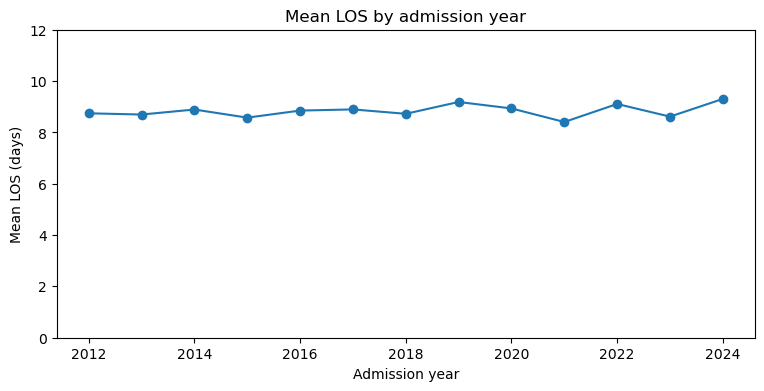

In [26]:
df["year"] = df["admission_date"].dt.year

df.groupby("year")["actual_los"].mean().plot(
    marker="o", figsize=(9, 4), ylim=(0, 12),
    title="Mean LOS by admission year",
    xlabel="Admission year", ylabel="Mean LOS (days)")


In [27]:
OUT_DIR = Path.cwd().parent / "Output"
df.to_csv(OUT_DIR / "patient_history_prepared.csv", index=False)
print(f"saved {df.shape[0]} rows x {df.shape[1]} columns")


saved 6825 rows x 37 columns
